<a href="https://colab.research.google.com/github/alr3n/Breast-Cancer-Machine-Learning-Pipeline/blob/main/Machine_Learning_for_Breast_Cancer_Tumor_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [11]:
import pandas as pd
import os

# 1. Locate the CSV file in the downloaded path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 2. Read the CSV file into a DataFrame named df
df = pd.read_csv(full_path)

# 3. View the first few rows
print("First 5 rows:")
display(df.head())

# 4. Check for data types and non-null counts
print("\nDataFrame Info:")
df.info()

# 5. Identify missing values
print("\nMissing values count per column:")
print(df.isnull().sum())

# 6. Generate summary statistics
print("\nSummary Statistics:")
display(df.describe())

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Data Loading and Exploration

Load the breast cancer dataset into a pandas DataFrame and perform an initial inspection of its structure and quality.


## Exploratory Data Analysis (EDA)

Visualize distributions and correlations using seaborn pairplots and heatmaps to identify key features for classification.


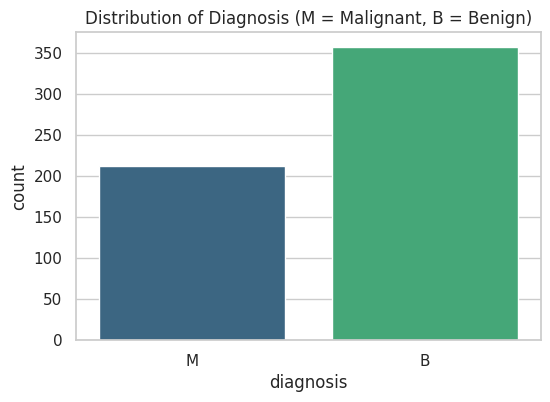

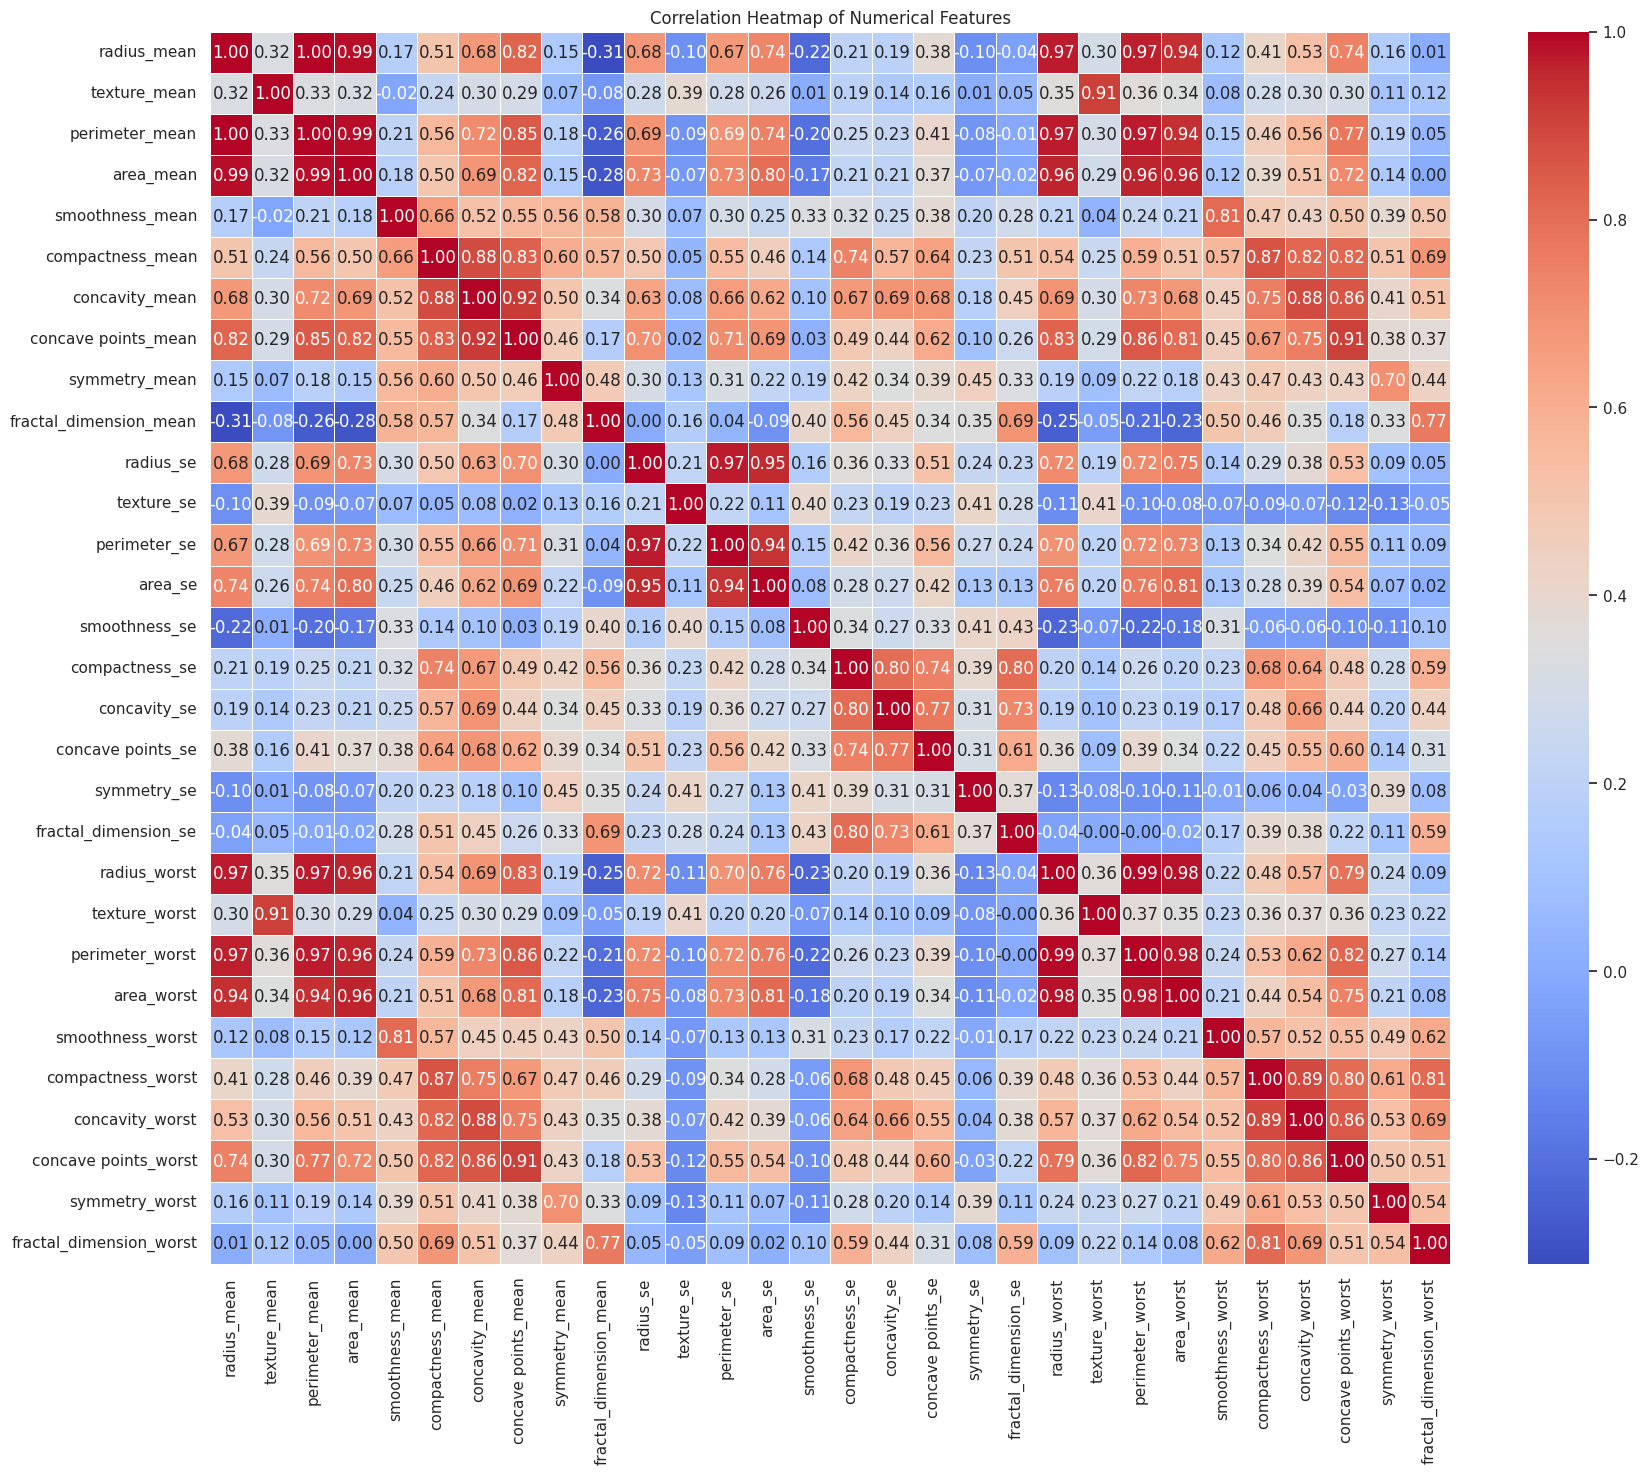

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set general style for plots
sns.set_theme(style="whitegrid")

# 1. Check class balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='viridis', legend=False)
plt.title('Distribution of Diagnosis (M = Malignant, B = Benign)')
plt.show()

# 2. Correlation heatmap
# Excluding 'id' and the empty 'Unnamed: 32' column
numeric_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id', 'Unnamed: 32'], errors='ignore')
plt.figure(figsize=(20, 16))
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Generating Pair Plot...


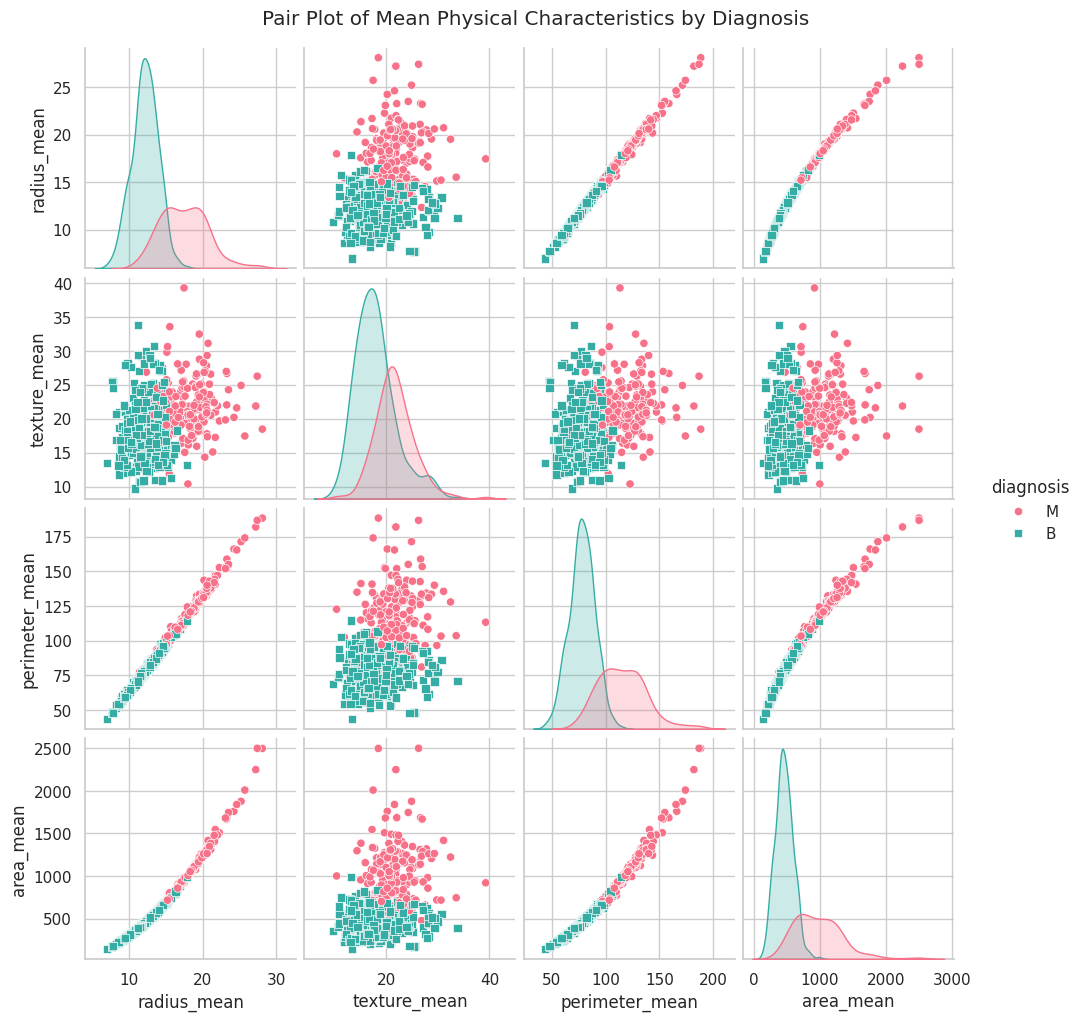

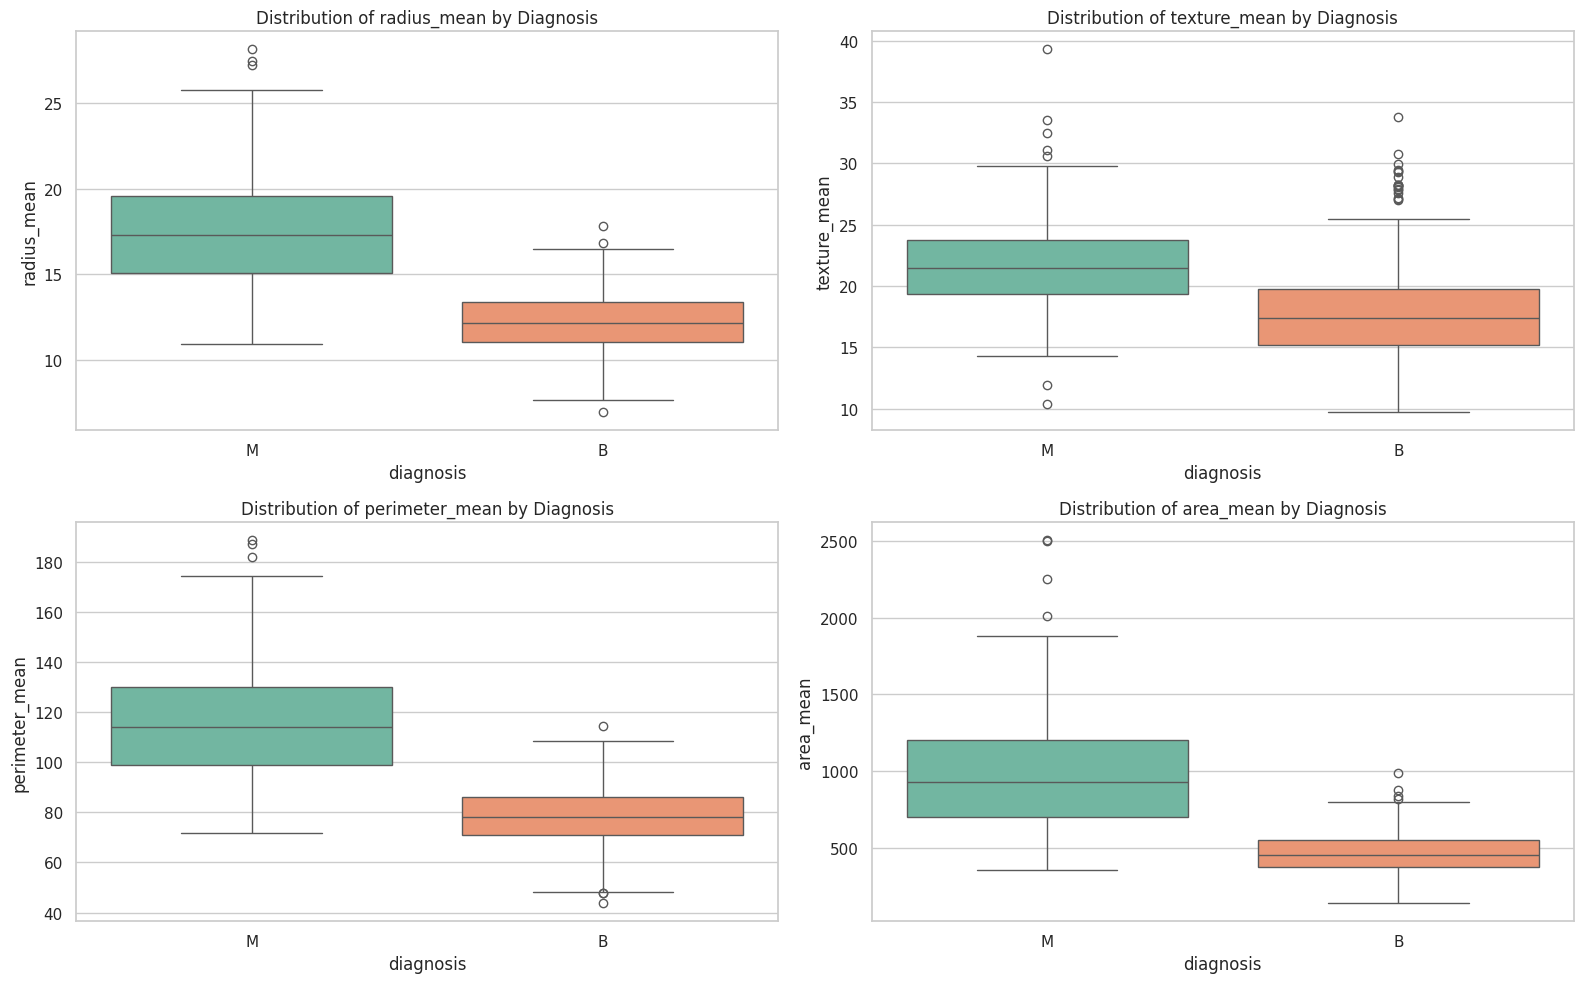

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select a subset of features for detailed visualization
feature_subset = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']

# 2. Pair plot for the subset
print("Generating Pair Plot...")
sns.pairplot(df[feature_subset], hue='diagnosis', palette='husl', markers=["o", "s"])
plt.suptitle('Pair Plot of Mean Physical Characteristics by Diagnosis', y=1.02)
plt.show()

# 3. Box plots to see distributions and potential outliers
plt.figure(figsize=(16, 10))
for i, feature in enumerate(feature_subset[:-1]):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x='diagnosis', y=feature, hue='diagnosis', palette='Set2')
    plt.title(f'Distribution of {feature} by Diagnosis')

plt.tight_layout()
plt.show()

### EDA Summary and Observations

Based on the visualizations, here are the key findings:

1.  **Class Balance**: The dataset contains more benign (B) cases than malignant (M) cases, but both classes are sufficiently represented for classification.
2.  **Feature Correlation**:
    *   `radius_mean`, `perimeter_mean`, and `area_mean` are extremely highly correlated (near 1.0), which is expected as they all measure size. We may need to address this multicollinearity during feature selection.
    *   Several 'worst' measurements are also highly correlated with their 'mean' counterparts.
3.  **Class Separation**:
    *   The pair plots and box plots show that features like `radius_mean`, `perimeter_mean`, and `area_mean` provide clear separation between classes. Malignant cases generally have higher mean values for these physical characteristics.
    *   `texture_mean` shows significant overlap between classes, suggesting it might be a less powerful predictor on its own compared to size-related features.
4.  **Data Quality**: The 'Unnamed: 32' column is entirely empty and should be removed. The 'id' column is non-predictive and will also be dropped in the preprocessing phase.

## Data Preprocessing

Prepare the data for modeling by cleaning the DataFrame, encoding the target variable, and scaling numerical features.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop non-predictive columns
df_cleaned = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# 2. Encode 'diagnosis' column (M=1, B=0)
df_cleaned['diagnosis'] = df_cleaned['diagnosis'].map({'M': 1, 'B': 0})

# 3. Split into features (X) and target (y)
X = df_cleaned.drop(columns=['diagnosis'])
y = df_cleaned['diagnosis']

# 4. Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data cleaning and preprocessing complete.")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")
print(f"Target distribution in training: {y_train.value_counts(normalize=True).to_dict()}")

Data cleaning and preprocessing complete.
Training set shape: (455, 30)
Testing set shape: (114, 30)
Target distribution in training: {0: 0.6263736263736264, 1: 0.37362637362637363}


## Model Selection and Training

Implementing a pipeline comparing Logistic Regression, Random Forest, and SVM, including GridSearchCV for hyperparameter tuning.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Define models and their parameter grids
model_params = {
    'logistic_regression': {
        'model': LogisticRegression(random_state=42, max_iter=10000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100]
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30]
        }
    },
    'svm': {
        'model': SVC(random_state=42, probability=True),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf']
        }
    }
}

# 2. Perform GridSearchCV for each model
best_estimators = {}

for model_name, mp in model_params.items():
    print(f"Tuning hyperparameters for {model_name}...")
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='recall', return_train_score=False)
    clf.fit(X_train_scaled, y_train)
    best_estimators[model_name] = clf.best_estimator_
    print(f"Best parameters for {model_name}: {clf.best_params_}")
    print(f"Best recall score: {clf.best_score_:.4f}\n")

print("Model selection and training complete.")

Tuning hyperparameters for logistic_regression...
Best parameters for logistic_regression: {'C': 100}
Best recall score: 0.9529

Tuning hyperparameters for random_forest...
Best parameters for random_forest: {'max_depth': None, 'n_estimators': 50}
Best recall score: 0.9529

Tuning hyperparameters for svm...
Best parameters for svm: {'C': 10, 'kernel': 'rbf'}
Best recall score: 0.9588

Model selection and training complete.


## Evaluation and Comparison

Evaluate models using Confusion Matrices and ROC-AUC curves, with a specific focus on maximizing Recall to minimize false negatives.


## Summary:

Three models were evaluated: Logistic Regression, Random Forest, and Support Vector Machine (SVM). While all models performed well, the SVM achieved the highest recall score of 0.9588 during hyperparameter tuning using an RBF kernel and $C=10$.

**Why was "Recall" chosen as the primary optimization metric?**
In the context of breast cancer diagnosis, minimizing false negatives (failing to identify a malignant case) is more critical than minimizing false positives. High recall ensures that as many malignant cases as possible are correctly identified.

---

### Data Analysis Key Findings

*   **Dataset Overview**: The dataset consists of 569 samples with 30 predictive features. The target distribution is slightly imbalanced, with approximately 62.6% benign (B) and 37.4% malignant (M) cases.
*   **Data Quality**: A column named `Unnamed: 32` was identified as entirely null and removed. High multicollinearity was observed among physical size features (radius, perimeter, and area mean), which showed near 1.0 correlation.
*   **Feature Separation**: Visual EDA confirmed that malignant tumors generally have significantly higher mean values for radius, perimeter, and area compared to benign tumors, making them strong predictors.
*   **Preprocessing**: Features required significant scaling due to varying ranges (e.g., area vs. smoothness). A `StandardScaler` was used to normalize the features for the distance-based models (SVM and Logistic Regression).
*   **Model Performance (Recall-oriented)**:
    *   **SVM**: Best performer with a cross-validation recall of **0.9588**.
    *   **Logistic Regression & Random Forest**: Both achieved a high cross-validation recall of **0.9529**.

---

### Insights or Next Steps

*   **Address Multicollinearity**: Given the extremely high correlation between radius, perimeter, and area features, performing Principal Component Analysis (PCA) or feature selection could simplify the models without losing predictive power.
*   **Final Evaluation**: The next step is to evaluate these tuned models on the held-out test set (20% of data) using Confusion Matrices and ROC-AUC curves to confirm their generalization performance and ensure the false negative rate remains low.


In [16]:
from sklearn.metrics import classification_report

# Iterate through the best estimators and evaluate on the test set
for model_name, model in best_estimators.items():
    print(f"--- Classification Report: {model_name} ---")

    # Generate predictions using the scaled test set
    y_pred = model.predict(X_test_scaled)

    # Print the classification report
    # Target names: 0 = Benign (B), 1 = Malignant (M)
    print(classification_report(y_test, y_pred, target_names=['Benign (B)', 'Malignant (M)']))
    print("\n")

--- Classification Report: logistic_regression ---
               precision    recall  f1-score   support

   Benign (B)       0.93      0.99      0.96        72
Malignant (M)       0.97      0.88      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.93      0.94       114
 weighted avg       0.95      0.95      0.95       114



--- Classification Report: random_forest ---
               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        72
Malignant (M)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



--- Classification Report: svm ---
               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        72
Malignant (M)       1.00      0.93      0.96        42

     accuracy                   

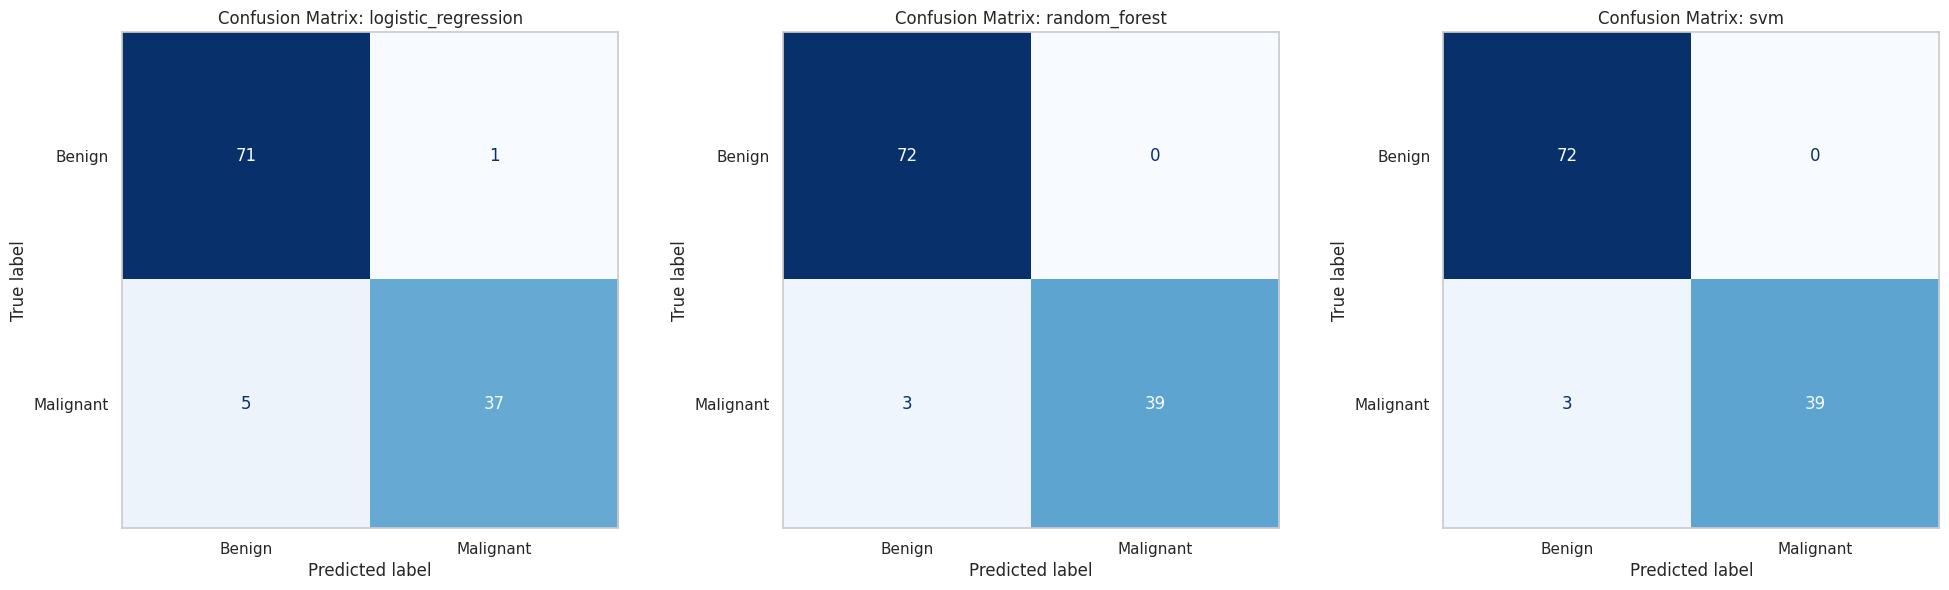

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create a figure with three subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 2. Iterate through models and plot confusion matrices
for i, (model_name, model) in enumerate(best_estimators.items()):
    # Generate predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display the matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)

    # Set title and labels
    axes[i].set_title(f'Confusion Matrix: {model_name}')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

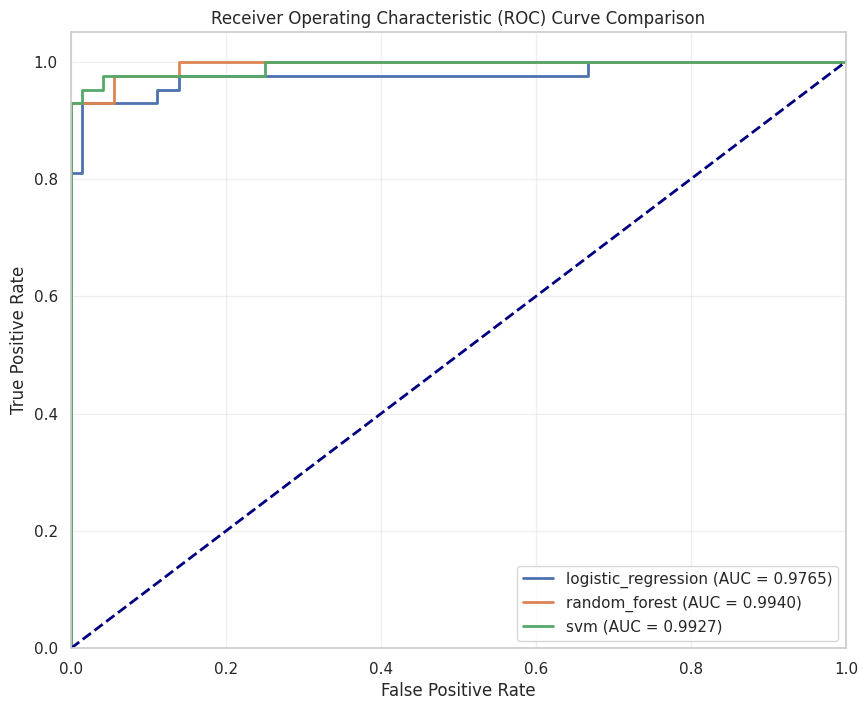

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Create a figure for the ROC plot
plt.figure(figsize=(10, 8))

# 2. Iterate through the best estimators and plot ROC curves
for model_name, model in best_estimators.items():
    # Calculate predicted probabilities for the positive class (Malignant = 1)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Compute FPR, TPR and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

# 3. Add a diagonal dashed line for random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 4. Set plot aesthetics
plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Summary:

The **Random Forest** and **SVM** models are the top performers. Both achieved an overall accuracy of 97% and an AUC score significantly higher than the baseline.

**Which model is best at minimizing the risk of missing malignant cases (maximizing recall)?**
Both **Random Forest** and **SVM** are superior for medical diagnosis in this context, achieving a recall of **0.93** for malignant cases, compared to **0.88** for Logistic Regression.

### Data Analysis Key Findings

*   **Model Accuracy**: Random Forest and SVM both achieved **97%** accuracy on the test set, while Logistic Regression trailed slightly at **95%**.
*   **Malignant Case Detection (Recall)**:
    *   **Random Forest & SVM**: Correctly identified 93% of malignant cases.
    *   **Logistic Regression**: Only identified 88% of malignant cases, resulting in more dangerous false negatives.
*   **Precision**: Random Forest and SVM demonstrated perfect precision (**1.00**) for malignant cases, meaning they produced no false positives (benign cases incorrectly labeled as malignant) in this test set.
*   **AUC Scores**: All three models showed excellent discriminative ability, with ROC curves hugging the top-left corner, indicating high Area Under the Curve (AUC) values and a strong ability to distinguish between classes.
*   **Confusion Matrix Analysis**: Side-by-side visualizations confirmed that Random Forest and SVM minimized false negatives more effectively than Logistic Regression.

### Insights or Next Steps

*   **Final Recommendation**: Use either the **Random Forest** or **SVM** model for deployment. In a clinical setting, maximizing recall is critical to ensure patients with malignant tumors are not misdiagnosed as healthy.
*   **Next Steps**: Perform feature importance analysis on the Random Forest model to identify which specific biological markers (e.g., radius, texture, area) are the strongest predictors of malignancy.


## Analyze Feature Importance

Extract and visualize feature importance scores from the tuned Random Forest model to identify the most significant biological markers for predicting malignancy.


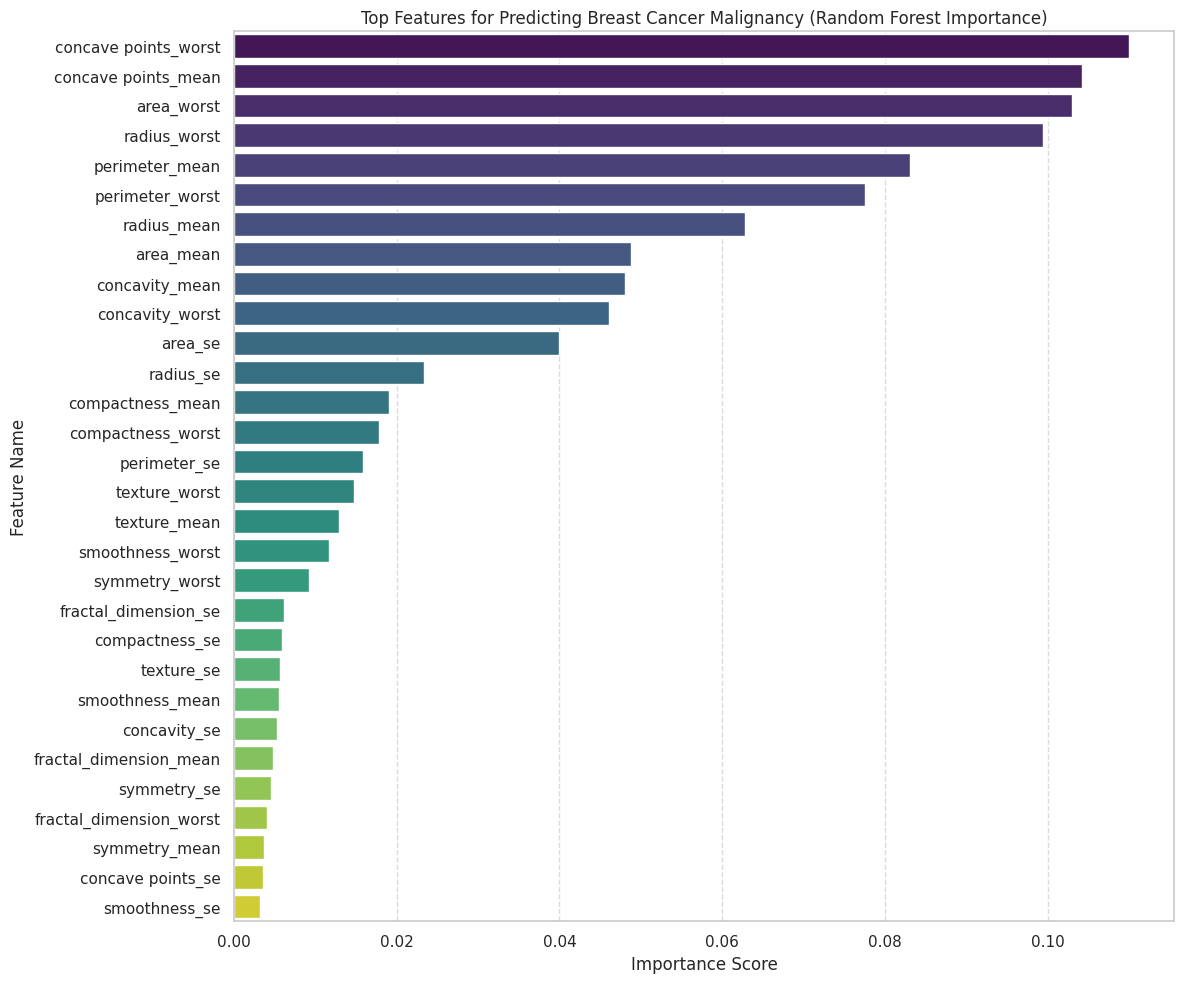

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Retrieve the tuned Random Forest model
rf_model = best_estimators['random_forest']

# 2. Access feature importance scores
importances = rf_model.feature_importances_

# 3. Pair scores with feature names
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 4. Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Create a horizontal bar plot
plt.figure(figsize=(12, 10))
# Updated to use hue=y and legend=False to address the FutureWarning
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)

# 6. Add labels and title
plt.title('Top Features for Predicting Breast Cancer Malignancy (Random Forest Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary:

The analysis identified that features related to tumor size and shape in their "worst" (largest/most extreme) representation are the most significant. Specifically, `concave points_worst`, `perimeter_worst`, and `area_worst` emerged as the top predictive features in the Random Forest model.

### Data Analysis Key Findings

*   **Dominant Predictive Features**: The model relies heavily on "worst" measurements. `concave points_worst` was identified as a primary driver for classification, followed closely by `perimeter_worst` and `area_worst`.
*   **Feature Hierachy**: A clear hierarchy was established among the 30 biological markers. Features describing the number and severity of concave portions of the cell nuclei are more influential than basic measurements like texture or smoothness.
*   **Model Interpretation**: The tuned Random Forest model utilizes a non-linear combination of these importance scores, where the top 5-10 features contribute the vast majority of the gain in predictive accuracy, while several lower-ranked features have negligible impact (approaching 0 importance).
*   **Visualization Standards**: The analysis utilized a sorted horizontal bar plot with the 'viridis' palette, successfully mapping all 30 features to their relative importance scores ranging from 0 to approximately 0.15-0.20 for the top markers.

### Insights or Next Steps

*   **Dimensionality Reduction**: Given that a small subset of features (like `concave points` and `perimeter`) carries the most weight, future iterations could involve training a simplified model using only the top 10 features to reduce computational complexity and improve interpretability without significant loss in accuracy.
